# Base de datos: Campañas de marketing directo (banca portuguesa)

## Integrantes:

    -   
    -   

# Introducción (aprendizaje no supervisado)

En este trabajo abordamos el conjunto de datos de campañas de marketing directo de una entidad bancaria portuguesa desde una **perspectiva no supervisada**. A diferencia de la clasificación tradicional —que utiliza la variable objetivo `subscribed`— aquí buscamos **descubrir estructuras latentes** en los datos sin recurrir a etiquetas: segmentar clientes, identificar patrones de contacto y reconocer perfiles con comportamientos similares que puedan guiar decisiones comerciales.

El objetivo principal es **construir segmentos accionables** que apoyen la planificación de campañas: qué perfiles conviene contactar, por qué canal y en qué momento, y cuáles muestran señales de baja respuesta. Para ello, combinamos atributos **demográficos** (`age`, `job`, `education`), de **historial de interacción** (`campaign`, `pdays`, `previous`, `poutcome`) y de **contexto macroeconómico** (`emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed`), evitando el uso de `duration` (porque induce fuga de información) y sin utilizar `subscribed` en el proceso de descubrimiento (solo podrá emplearse luego para **validación ex post** de los segmentos).

Dado que el conjunto mezcla **variables numéricas y categóricas**, el preprocesamiento es clave: tratamiento de valores `unknown`, codificación apropiada de categorías, y **escalado** de variables continuas. La exploración incluirá técnicas de **reducción de dimensionalidad** para visualizar la estructura global y algoritmos de **clustering** con evaluación interna y análisis de **interpretabilidad** (perfiles medios por cluster, importancia de rasgos).

El resultado esperado es un conjunto de **segmentos interpretables**, alineados con la realidad del negocio, que permitan diseñar estrategias diferenciadas de contacto y oferta, optimizando recursos y mejorando la eficacia de las campañas sin depender inicialmente de una etiqueta de éxito.


## Descripción general
Conjunto de datos de campañas de **marketing directo vía llamadas telefónicas** de una institución bancaria en Portugal. El objetivo típico es predecir si un cliente **suscribirá un depósito a plazo**.

- **Observación:** un contacto (cliente × campaña).
- **Variable ilustrativa:** `subscribed` (sí/no).

> **Importante (fuga de información):** la variable `duration` solo se conoce **durante/después** de la llamada y está fuertemente correlacionada con el resultado. Para un modelo **realista en producción**, **no** debe usarse como predictor; puede utilizarse solo para **benchmarks**.

---

## Diccionario de datos

| # | Variable | Tipo | Descripción | Valores posibles |
|---:|---|---|---|---|
| 1 | `age` | numérico | Edad del cliente. | — |
| 2 | `job` | categórica | Tipo de empleo. | `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown` |
| 3 | `marital` | categórica | Estado civil (*divorced* incluye divorciado/viudo). | `divorced`, `married`, `single`, `unknown` |
| 4 | `education` | categórica | Nivel educativo. | `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown` |
| 5 | `default` | categórica | ¿Crédito en mora/incumplimiento? | `no`, `yes`, `unknown` |
| 6 | `housing` | categórica | ¿Crédito hipotecario? | `no`, `yes`, `unknown` |
| 7 | `loan` | categórica | ¿Préstamo personal? | `no`, `yes`, `unknown` |
| 8 | `contact` | categórica | Canal del último contacto de la campaña actual. | `cellular`, `telephone` |
| 9 | `month` | categórica | Mes del último contacto. | `jan`, `feb`, `mar`, …, `nov`, `dec` |
|10 | `day_of_week` | categórica | Día de la semana del último contacto. | `mon`, `tue`, `wed`, `thu`, `fri` |
|11 | `duration` | numérico | Duración del último contacto (segundos). **Ver nota de fuga.** | — |
|12 | `campaign` | numérico | # de contactos en **esta** campaña (incluye el último). | — |
|13 | `pdays` | numérico | Días desde el último contacto en campañas previas (`999` = nunca contactado). | — |
|14 | `previous` | numérico | # de contactos **previos** a esta campaña. | — |
|15 | `poutcome` | categórica | Resultado de la campaña previa. | `failure`, `nonexistent`, `success` |
|16 | `emp.var.rate` | numérico | Tasa de variación del empleo (trimestral). | — |
|17 | `cons.price.idx` | numérico | Índice de precios al consumidor (mensual). | — |
|18 | `cons.conf.idx` | numérico | Índice de confianza del consumidor (mensual). | — |
|19 | `euribor3m` | numérico | Tasa Euribor a 3 meses (diaria). | — |
|20 | `nr.employed` | numérico | Número de empleados (trimestral). | — |
|21 | `subscribed` | binaria (objetivo) | ¿Suscribió depósito a plazo? | `yes`, `no` |

---

## Notas de modelado
- **Predictores recomendados:** variables demográficas (`age`, `job`, `education`, etc.), historial de campañas (`campaign`, `pdays`, `previous`, `poutcome`) y contexto macro (`emp.var.rate`, `euribor3m`, etc.).
- **Evitar en producción:** `duration` (conduce a **target leakage**).
- **Codificación:** tratar `unknown` como categoría explícita; considerar *one-hot encoding* para variables categóricas.
- **Escalas:** normalizar/estandarizar predictores continuos si se usan modelos sensibles a escala.


In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import prince
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score)

In [188]:
data = pd.read_csv("bank_marketing_dataset.csv")
data = data.drop(columns=['subscribed'])  # Eliminar columna irrelevante
pd.set_option('display.max_columns', None)
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


In [189]:
COLOR_PRIN = '#2a78d6'   # azul    - slot categórico 1
COLOR_SEC  = '#eb6834'   # naranja - slot categórico 2
COLOR_GRID = '#e1e0d9'
COLOR_AXIS = '#898781'
COLOR_TEXT = '#0b0b0b'
SURFACE    = '#fcfcfb'

plt.rcParams.update({
    'axes.edgecolor': COLOR_AXIS,
    'axes.labelcolor': COLOR_TEXT,
    'xtick.color': COLOR_AXIS,
    'ytick.color': COLOR_AXIS,
    'text.color': COLOR_TEXT,
    'axes.grid': True,
    'grid.color': COLOR_GRID,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
})


def clean_ax(ax):
    """Quita bordes superior/derecho y manda la grilla detrás de los datos."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)


# ✅ Criterios de evaluación – Aprendizaje no supervisado

1) **Análisis exploratorio completo y preparación de datos**  
Realiza un **EDA** que caracterice la distribución de variables, relaciones relevantes y posibles sesgos: incluye tendencias, dispersión, outliers, correlaciones/associaciones y calidad de datos (faltantes y categorías `unknown`). A partir de este diagnóstico, deja el dataset listo para agrupar: tratamiento de faltantes, codificación de categóricas y escalado de continuas, justificando cada decisión y evitando fugas de información (no usar `subscribed` ni `duration` como insumo del clustering).

2) **Proyección y visualización de la estructura**  
Emplea una técnica de reducción de dimensionalidad (p. ej., PCA o UMAP) para explorar la forma global de los datos y sugerir separaciones naturales. Presenta visualizaciones claras que faciliten interpretar la estructura latente.

3) **Modelado de clusters**  
Selecciona y ejecuta un algoritmo acorde al tipo de variables (p. ej., k-means/k-medoids, k-prototypes, DBSCAN o mezcla gaussiana). Define y justifica los hiperparámetros (incluido el número de clusters cuando aplique) y reporta la estabilidad/consistencia de la solución.

4) **Descripción de los clusters**  
Perfila cada segmento en términos de sus rasgos distintivos (demografía, historial de campañas y contexto). Entrega un resumen comparativo (tablas/gráficos) que muestre claramente cómo difieren los clusters. **Las acciones comerciales derivadas** deberán ser propuestas aparte por los estudiantes; aquí se califica la **calidad y claridad de la descripción**.


### Punto 1

In [190]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [191]:
data.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

In [192]:
def contar_valor(df, valor):
    conteo = (df == valor).sum()
    return pd.DataFrame({
        "Conteo": conteo,
        "%": (conteo / len(df) * 100).round(2),
    }).sort_values("Conteo", ascending=False)

contar_valor(data, 'unknown')

,Conteo,%
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19
age,0,0.00
contact,0,0.00
month,0,0.00
day_of_week,0,0.00


In [193]:
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [194]:
cat_cols = data.select_dtypes(include=['str']).columns
for col in (cat_cols):
    print(f"\nTop 5 valores más frecuentes en '{col}':\n")
    print(data[col].value_counts().head())



Top 5 valores más frecuentes en 'job':

job
admin.         10422
blue-collar     9254
technician      6743
services        3969
management      2924
Name: count, dtype: int64

Top 5 valores más frecuentes en 'marital':

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Top 5 valores más frecuentes en 'education':

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
Name: count, dtype: int64

Top 5 valores más frecuentes en 'default':

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Top 5 valores más frecuentes en 'housing':

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

Top 5 valores más frecuentes en 'loan':

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

Top 5 valores más frecuentes en 'contact':

contact
cellular

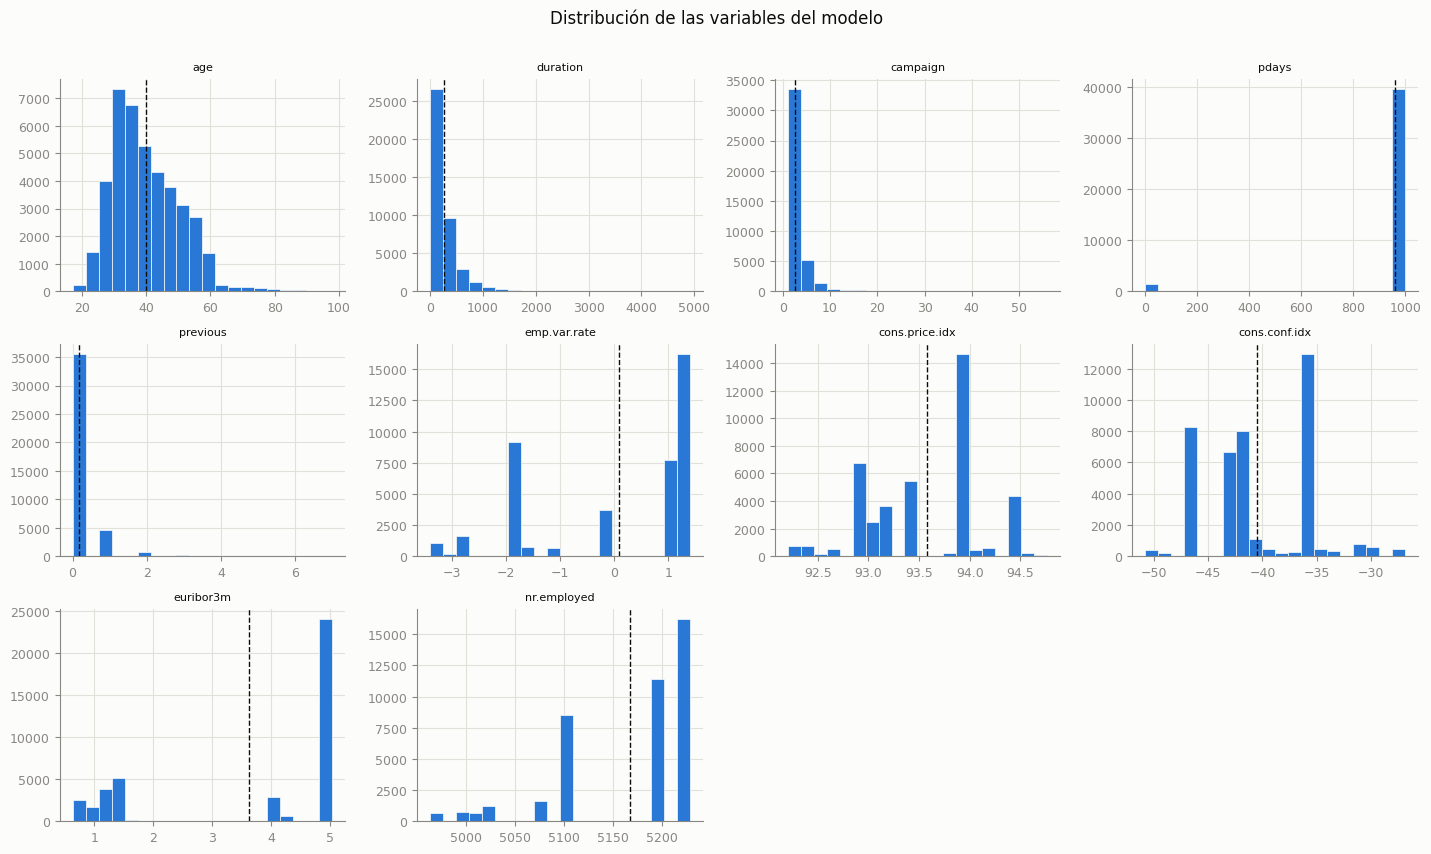

In [195]:
# ---------------------------------------------------------------
# Histogramas
# ---------------------------------------------------------------
n_cols = 4
n_vars = len(num_cols)
n_rows = -(-n_vars // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.6, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    datos = data[col].dropna()
    ax = axes[i]
    ax.hist(datos, bins=20, color=COLOR_PRIN, edgecolor=SURFACE, linewidth=0.5)
    ax.axvline(datos.mean(), color=COLOR_TEXT, linewidth=1, linestyle='--')
    ax.set_title(col, fontsize=8)
    clean_ax(ax)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Distribución de las variables del modelo', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

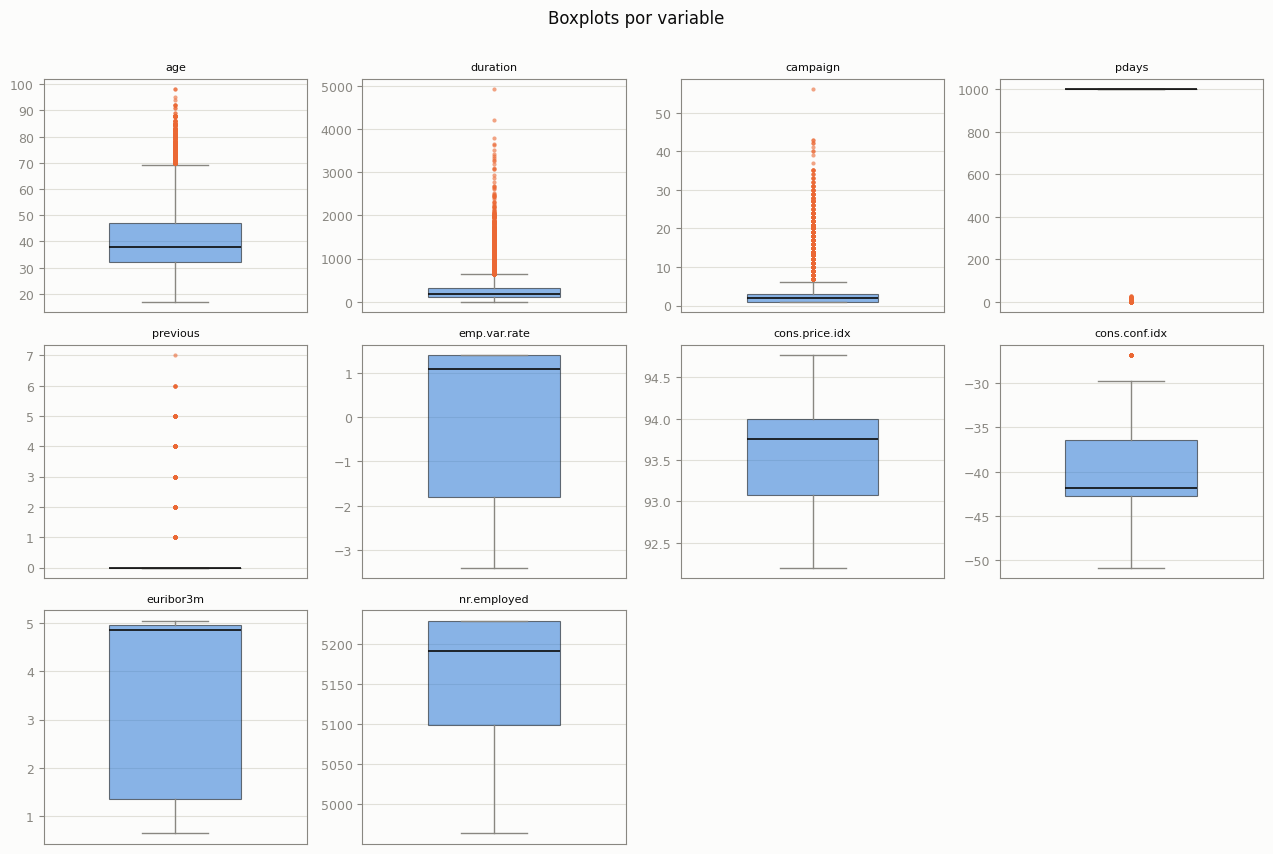

In [196]:
# ---------------------------------------------------------------
# Boxplots
# ---------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    datos = data[col].dropna()
    ax = axes[i]
    ax.boxplot(
        datos, vert=True, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor=COLOR_PRIN, alpha=0.55, edgecolor=COLOR_TEXT, linewidth=0.8),
        medianprops=dict(color=COLOR_TEXT, linewidth=1.2),
        whiskerprops=dict(color=COLOR_AXIS),
        capprops=dict(color=COLOR_AXIS),
        flierprops=dict(markerfacecolor=COLOR_SEC, markeredgecolor='none',
                        markersize=3, alpha=0.6),
    )
    ax.set_title(col, fontsize=8)
    ax.set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Boxplots por variable', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

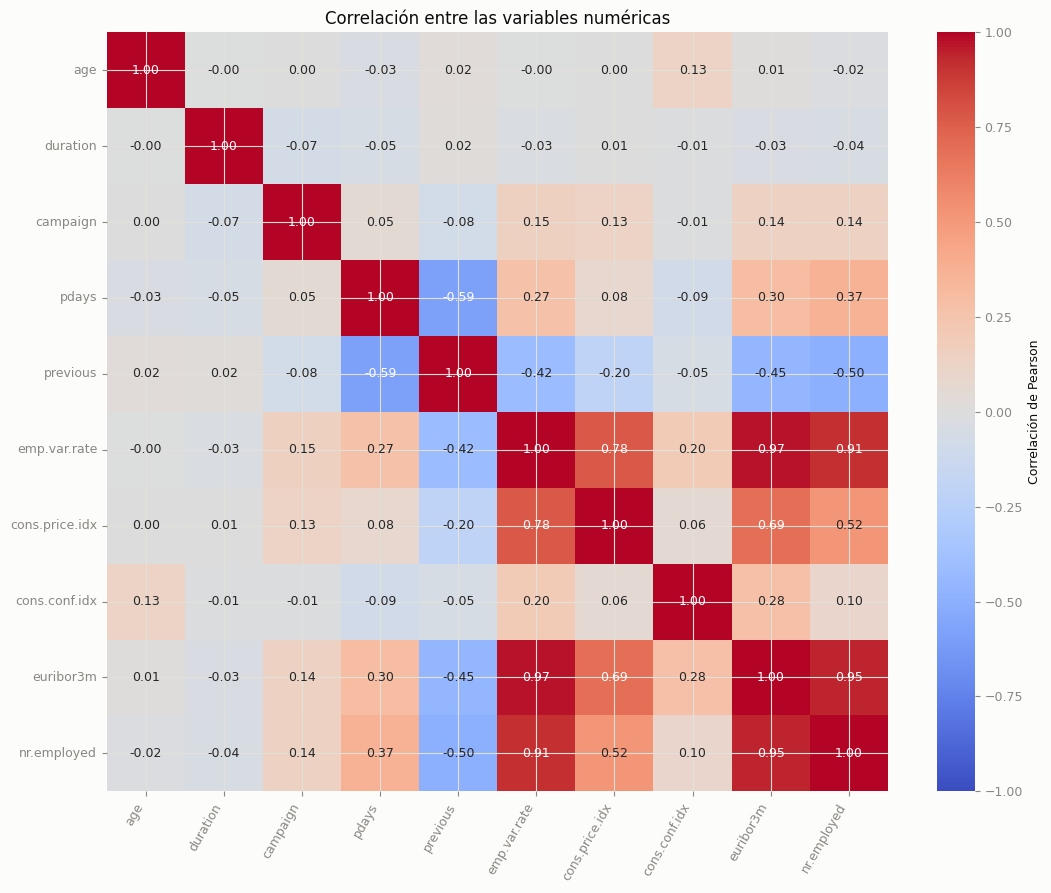

In [197]:
# ---------------------------------------------------------------
# Correlación entre las variables numéricas
# ---------------------------------------------------------------
matriz_corr = data[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    matriz_corr, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
    cbar_kws={"label": "Correlación de Pearson"},
)
ax.set_title('Correlación entre las variables numéricas', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [198]:
UMBRAL_Z = 3.0

resumen = []
for col in num_cols:
    datos = data[col]
    z = (datos - datos.mean()) / datos.std()
    mascara = z.abs() > UMBRAL_Z
    resumen.append({
        "Variable": col,
        "Media": datos.mean(),
        "Desv. est.": datos.std(),
        "Límite inferior": datos.mean() - UMBRAL_Z * datos.std(),
        "Límite superior": datos.mean() + UMBRAL_Z * datos.std(),
        'Min': datos.min(),
        'Max': datos.max(),
        "Atípicos": int(mascara.sum()),
        "% del total": round(100 * mascara.mean(), 2)
    })

resumen = pd.DataFrame(resumen).sort_values("Atípicos", ascending=False)
display(resumen.round(3))

,Variable,Media,Desv. est.,Límite inferior,Límite superior,Min,Max,Atípicos,% del total
3,pdays,962.475,186.911,401.743,1523.208,0.000,999.000,1515,3.68
4,previous,0.173,0.495,-1.312,1.658,0.000,7.000,1064,2.58
2,campaign,2.568,2.770,-5.742,10.878,1.000,56.000,869,2.11
1,duration,258.285,259.279,-519.553,1036.123,0.000,4918.000,861,2.09
0,age,40.024,10.421,8.760,71.288,17.000,98.000,369,0.90
5,emp.var.rate,0.082,1.571,-4.631,4.795,-3.400,1.400,0,0.00
6,cons.price.idx,93.576,0.579,91.839,95.312,92.201,94.767,0,0.00
7,cons.conf.idx,-40.503,4.628,-54.387,-26.618,-50.800,-26.900,0,0.00
8,euribor3m,3.621,1.734,-1.582,8.825,0.634,5.045,0,0.00
9,nr.employed,5167.036,72.252,4950.281,5383.790,4963.600,5228.100,0,0.00


In [199]:
data['pdays'].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

In [200]:
df = data.copy()

df['pweeks'] = pd.cut(
    df['pdays'],
    bins=[0, 7, 14, 21, 28, 1000],
    labels=['una_semana', 'dos_semanas', 'tres_semanas', 'cuatro_semanas', 'nunca'],
    right=False   # intervalo [a, b) no [a, b]
)
df = df.drop(columns=['pdays', 'duration'])

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.to_list()
cat_cols = df.select_dtypes(include=['str', 'category']).columns.to_list()
print("Numericas:\n", num_cols)
print("\nCategoricas:\n", cat_cols)

Numericas:
 ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categoricas:
 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'pweeks']


### Punto 2

In [201]:
scaler = StandardScaler()

df_esc = df.copy()
df_esc[num_cols] = scaler.fit_transform(df_esc[num_cols])

Usamos `StandardScaler()` para escalar todas las variables y dejar el DataFrame escalado en `df_esc`

In [202]:
n_num = len(num_cols)
K = len(cat_cols)
J = int(sum(df_esc[c].nunique() for c in cat_cols))
n_max = n_num + (J - K)

print(f"Numéricas: {n_num} | Categóricas: {K} | Categorías: {J}")
print(f"Dimensiones del FAMD: {n_max}")

modelo_full = prince.FAMD(n_components=n_max, random_state=42).fit(df_esc)

eig = np.asarray(modelo_full.eigenvalues_, dtype=float)
inercia_pct = eig / eig.sum() * 100
acum = inercia_pct.cumsum()

print(f"Factores calculados: {len(eig)}")
print(f"Inercia total: {eig.sum():.2f}")

# ---------------------------------------------------------------
# Criterios de decisión
# ---------------------------------------------------------------
n_kaiser = int((eig > 1).sum())

# Diferencias sucesivas: dónde está el escalón más grande
saltos = -np.diff(eig)
n_codo = int(np.argmax(saltos) + 1)

print(f"\nKaiser (eig > promedio) -> {n_kaiser} factores")
print(f"Mayor caída entre factores consecutivos: F{n_codo} -> F{n_codo+1}")

diag_famd = pd.DataFrame({
    "Factor": [f"F{i}" for i in range(1, len(eig) + 1)],
    "Eigenvalue": eig.round(4),
    "Inercia (%)": inercia_pct.round(2),
    "Acumulada (%)": acum.round(2),
    "Caída al siguiente": np.append(saltos, np.nan).round(4),
    "Eigenvalue > 1": eig > 1,
})
display(diag_famd)

Numéricas: 8 | Categóricas: 11 | Categorías: 58
Dimensiones del FAMD: 55
Factores calculados: 55
Inercia total: 55.00

Kaiser (eig > promedio) -> 23 factores
Mayor caída entre factores consecutivos: F1 -> F2


,Factor,Eigenvalue,Inercia (%),Acumulada (%),Caída al siguiente,Eigenvalue > 1
0,F1,5.0695,9.22,9.22,2.8245,True
1,F2,2.2450,4.08,13.30,0.1162,True
2,F3,2.1288,3.87,17.17,0.1239,True
3,F4,2.0049,3.65,20.81,0.0657,True
4,F5,1.9392,3.53,24.34,0.4059,True
5,F6,1.5333,2.79,27.13,0.0417,True
6,F7,1.4916,2.71,29.84,0.0849,True
7,F8,1.4067,2.56,32.40,0.0485,True
8,F9,1.3582,2.47,34.87,0.0699,True
9,F10,1.2883,2.34,37.21,0.0775,True


Usamos FAMD (Factor Analysis for Mixed Data, o Análisis de Factores para Datos Mixtos), que, como su nombre lo dice, sirve para variables mixtas, osea categóricas y numéricas, como las tenemos en este caso. FAMD es como una combinación entre ACP y ACM. Lo que hace es que reduce las dimensiones de todos los datos, sean variables categóricas o numéricas. Para FAMD no usamos la inercia, como si se hace con ACP, debido a que hay variables categóricas (así como en ACM que no se mira la inercia). Para este caso usamos el criterio de Kaiser, que mira lo Eigenvalues. Entonces, para decidir el número de componentes, se escogen todos los que tengan un Eigenvalue mayor a 1. Para este caso, pasamos de tener 58 categorías (repartidas en 11 variables categóricas) y 8 variables numéricas (para un total de 64 "variables" distintas), a tener 23 componentes.

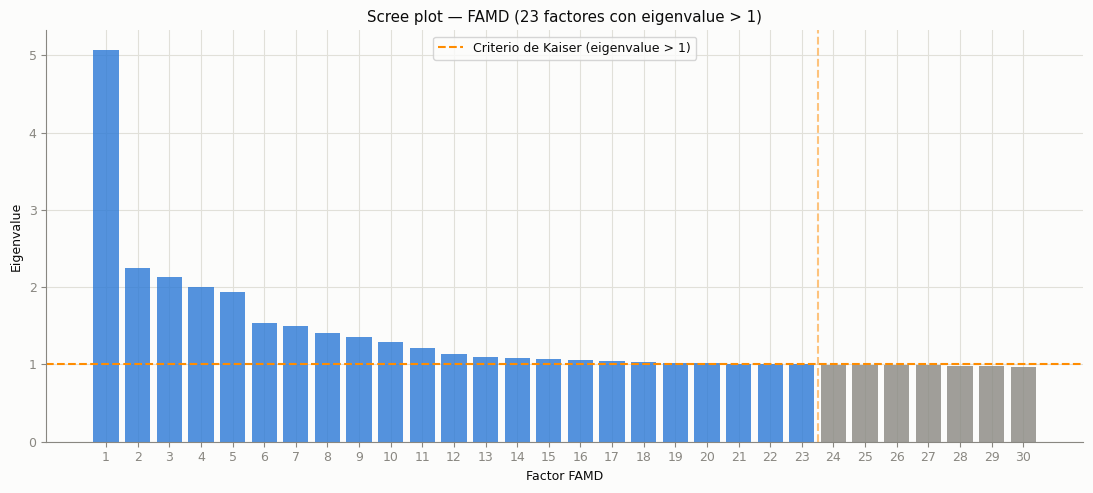

In [203]:
# ---------------------------------------------------------------
# Scree plot
# ---------------------------------------------------------------
n_mostrar = min(30, len(eig))
factores = np.arange(1, n_mostrar + 1)

fig, ax = plt.subplots(figsize=(11, 5))
colores_barra = [COLOR_PRIN if e > 1 else COLOR_AXIS for e in eig[:n_mostrar]]
ax.bar(factores, eig[:n_mostrar], color=colores_barra, alpha=0.8)
ax.axhline(1, color="darkorange", linestyle="--",
           label="Criterio de Kaiser (eigenvalue > 1)")
ax.axvline(n_kaiser + 0.5, color="darkorange", linestyle="--", alpha=0.5)
ax.set_xlabel("Factor FAMD")
ax.set_ylabel("Eigenvalue")
ax.set_xticks(factores)
ax.set_title(f"Scree plot — FAMD ({n_kaiser} factores con eigenvalue > 1)")
ax.legend()
clean_ax(ax)
plt.tight_layout()
plt.show()

Como dijimos antes, la inercia no es un criterio muy útil en este caso. Podemos ver acá con el `Scree Plot`, ya que es difícil escoger un número de componentes usando el método del codo. A simple vista podríamos escoger 2 compnentes porque hay un cambio muy drástico, o depronto 6 si queremos dejar más margen. Pero si hubiéramos visto con la inercia acumulada (y estableciendo un umbral de 85%), nos habríamos quedado con 36 factores. Para eso tenemos el método de Kaiser que nos ayuda porque un Eigenvalue < 1 nos dice que explica menos varianza que una variable individual, osea que básicamente hubiera sido mejor quedarnos con las variables originales en vez de ponerse a inventar.

In [204]:
# ---------------------------------------------------------------
# Proyección final y significado de los primeros factores
# ---------------------------------------------------------------
N_FACTORES = n_kaiser              # decisión explícita: eigenvalue > 1

modelo = prince.FAMD(n_components=N_FACTORES, random_state=42).fit(df_esc)
df_modelo = modelo.row_coordinates(df_esc)
df_modelo.columns = [f"F{i}" for i in range(1, N_FACTORES + 1)]
df_modelo.index = df_esc.index

print(f"Antes del FAMD:  {df_esc.shape}")
print(f"Después del FAMD: {df_modelo.shape}")
print(f"Inercia retenida: {acum[N_FACTORES-1]:.2f} % "
      f"(escala FAMD, no comparable con la de un ACP)")

n_ver = min(4, N_FACTORES)

# Numéricas: correlación con cada factor
corr_num = pd.DataFrame(
    {f: [df_esc[c].corr(df_modelo[f]) for c in num_cols]
     for f in df_modelo.columns[:n_ver]},
    index=num_cols,
)
print("\nCorrelación de las variables numéricas con los primeros factores:")
display(corr_num.round(3))

# Categóricas: centroide de cada categoría en el espacio factorial
bloques = []
for c in cat_cols:
    g = df_modelo.iloc[:, :n_ver].groupby(df_esc[c].values).mean()
    g.index = [f"{c} = {i}" for i in g.index]
    bloques.append(g)
coord_cat = pd.concat(bloques)

print("\nCategorías que más definen F1 y F2:")
display(coord_cat.reindex(
    coord_cat.iloc[:, :2].abs().sum(axis=1).sort_values(ascending=False).index
).round(3).head(15))

Antes del FAMD:  (41188, 19)
Después del FAMD: (41188, 23)
Inercia retenida: 62.30 % (escala FAMD, no comparable con la de un ACP)

Correlación de las variables numéricas con los primeros factores:


,F1,F2,F3,F4
age,-0.009,0.447,0.267,-0.328
campaign,-0.187,0.019,-0.026,0.019
previous,0.658,0.329,-0.003,0.063
emp.var.rate,-0.920,0.148,-0.162,0.034
cons.price.idx,-0.715,0.302,0.063,0.125
cons.conf.idx,-0.173,0.505,-0.350,-0.028
euribor3m,-0.924,0.138,-0.186,0.018
nr.employed,-0.895,-0.038,-0.158,-0.005



Categorías que más definen F1 y F2:


,F1,F2,F3,F4
pweeks = una_semana,5.747,5.400,-1.649,0.587
poutcome = success,5.649,5.181,-1.543,0.688
pweeks = tres_semanas,5.501,3.727,-1.669,0.719
pweeks = dos_semanas,5.427,3.637,-0.633,1.092
pweeks = cuatro_semanas,5.060,3.619,-1.273,0.902
month = sep,4.475,2.969,-0.802,0.190
month = dec,4.543,2.397,-0.458,-0.230
month = oct,3.995,2.138,-0.437,-0.073
month = apr,2.744,-1.577,1.077,-0.233
poutcome = failure,3.265,-0.635,0.728,-0.032


Aunque no nos sirva para perfilar los clusters, acá se puede ver un poco la distribución de las variables numéricas originales, y algunas de las categorías, dentro de cada uno de los factores. Por ejemplo, se puede ver que el factor 1 no se define tanto por variables como la edad, los contactos de la campaña actual ni el índice de confianza del consumidor; no tampoco por los clientes que están retirados o que no se sabe su empleo.

### Punto 3

In [205]:
'''# Rápido: ajusta dos modelos con distintos N_FACTORES
for n_f in [5, 15, 20, 23]:
    modelo_temp = prince.FAMD(n_components=n_f, random_state=42).fit(df_esc)
    coords_temp = modelo_temp.row_coordinates(df_esc)

    inercia_total = KMeans(n_clusters=1, random_state=42, n_init=10).fit(coords_temp).inertia_
    print("Inercia total (K=1):", round(inercia_total, 2))

    rango_k = range(2, n_f)
    diagnostico_k = []

    for k in rango_k:
        modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
        etiquetas = modelo.fit_predict(coords_temp)
        diagnostico_k.append({
            "K": k,
            "Inercia (WCSS)": modelo.inertia_,
            "Inercia explicada (%)": 100 * (1 - modelo.inertia_ / inercia_total),
            "Silhouette": silhouette_score(coords_temp, etiquetas),
            "Calinski-Harabasz": calinski_harabasz_score(coords_temp, etiquetas),
            "Davies-Bouldin": davies_bouldin_score(coords_temp, etiquetas),
        })

    diagnostico_k = pd.DataFrame(diagnostico_k)
    diagnostico_k["Reducción vs K anterior (%)"] = (
        -diagnostico_k["Inercia (WCSS)"].pct_change() * 100
    )
    display(diagnostico_k.round(3))

    k_elegido = 9   # <-- fijar después de leer la tabla y los cuatro paneles

    paneles = [
        ("Inercia (WCSS)", "Método del codo", COLOR_PRIN, None),
        ("Silhouette", "Silhouette (mayor es mejor)", COLOR_SEC, "max"),
        ("Calinski-Harabasz", "Calinski-Harabasz (mayor es mejor)", COLOR_PRIN, "max"),
        ("Davies-Bouldin", "Davies-Bouldin (menor es mejor)", COLOR_SEC, "min"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, (col, titulo, color, optimo) in zip(axes.flatten(), paneles):
        ax.plot(diagnostico_k["K"], diagnostico_k[col], marker="o", color=color)
        if optimo == "max":
            k_opt = diagnostico_k.loc[diagnostico_k[col].idxmax(), "K"]
        elif optimo == "min":
            k_opt = diagnostico_k.loc[diagnostico_k[col].idxmin(), "K"]
        else:
            k_opt = None
        if k_opt is not None:
            ax.axvline(k_opt, color=COLOR_AXIS, linestyle=":", label=f"óptimo: K={k_opt}")
        ax.axvline(k_elegido, color="darkorange", linestyle="--",
                label=f"elegido: K={k_elegido}")
        ax.set_title(titulo, fontsize=10)
        ax.set_xlabel("K")
        ax.set_xticks(list(rango_k)[::2])
        ax.legend(fontsize=8)
        clean_ax(ax)

    plt.tight_layout()
    plt.show()
        
    # Clustering
    kmeans_temp = KMeans(n_clusters=k_elegido, random_state=42).fit(coords_temp)
    sil_temp = silhouette_score(coords_temp, kmeans_temp.labels_)
    print(f"N={n_f}: silhouette = {sil_temp:.3f}")'''

'# Rápido: ajusta dos modelos con distintos N_FACTORES\nfor n_f in [5, 15, 20, 23]:\n    modelo_temp = prince.FAMD(n_components=n_f, random_state=42).fit(df_esc)\n    coords_temp = modelo_temp.row_coordinates(df_esc)\n\n    inercia_total = KMeans(n_clusters=1, random_state=42, n_init=10).fit(coords_temp).inertia_\n    print("Inercia total (K=1):", round(inercia_total, 2))\n\n    rango_k = range(2, n_f)\n    diagnostico_k = []\n\n    for k in rango_k:\n        modelo = KMeans(n_clusters=k, random_state=42, n_init=10)\n        etiquetas = modelo.fit_predict(coords_temp)\n        diagnostico_k.append({\n            "K": k,\n            "Inercia (WCSS)": modelo.inertia_,\n            "Inercia explicada (%)": 100 * (1 - modelo.inertia_ / inercia_total),\n            "Silhouette": silhouette_score(coords_temp, etiquetas),\n            "Calinski-Harabasz": calinski_harabasz_score(coords_temp, etiquetas),\n            "Davies-Bouldin": davies_bouldin_score(coords_temp, etiquetas),\n        })\

Este está comentado porque solo lo usamos para ver cuál era la mejor división de los componentes principales y para mirar preliminarmente los criterios para escoger K. Está comentado porque se demora media hora o más en correr, pero hace parte del proceso que hicimos.

Inercia total (K=1): 1402156.93


,K,Inercia (WCSS),Inercia explicada (%),Silhouette,Calinski-Harabasz,Davies-Bouldin,Reducción vs K anterior (%)
0,2,1223905.367,12.713,0.183,5998.396,2.362,NaN
1,3,1137882.766,18.848,0.177,4782.625,2.036,7.029
2,4,1061773.532,24.276,0.188,4400.924,1.750,6.689
3,5,1000853.989,28.620,0.116,4128.191,2.019,5.738
4,6,964884.074,31.186,0.120,3732.629,2.019,3.594
5,7,935789.113,33.261,0.130,3420.556,2.139,3.015
6,8,923036.123,34.170,0.118,3053.618,1.875,1.363
7,9,884115.318,36.946,0.122,3016.075,2.014,4.217
8,10,860607.059,38.623,0.124,2879.099,2.138,2.659
9,11,839259.374,40.145,0.134,2761.773,2.016,2.481


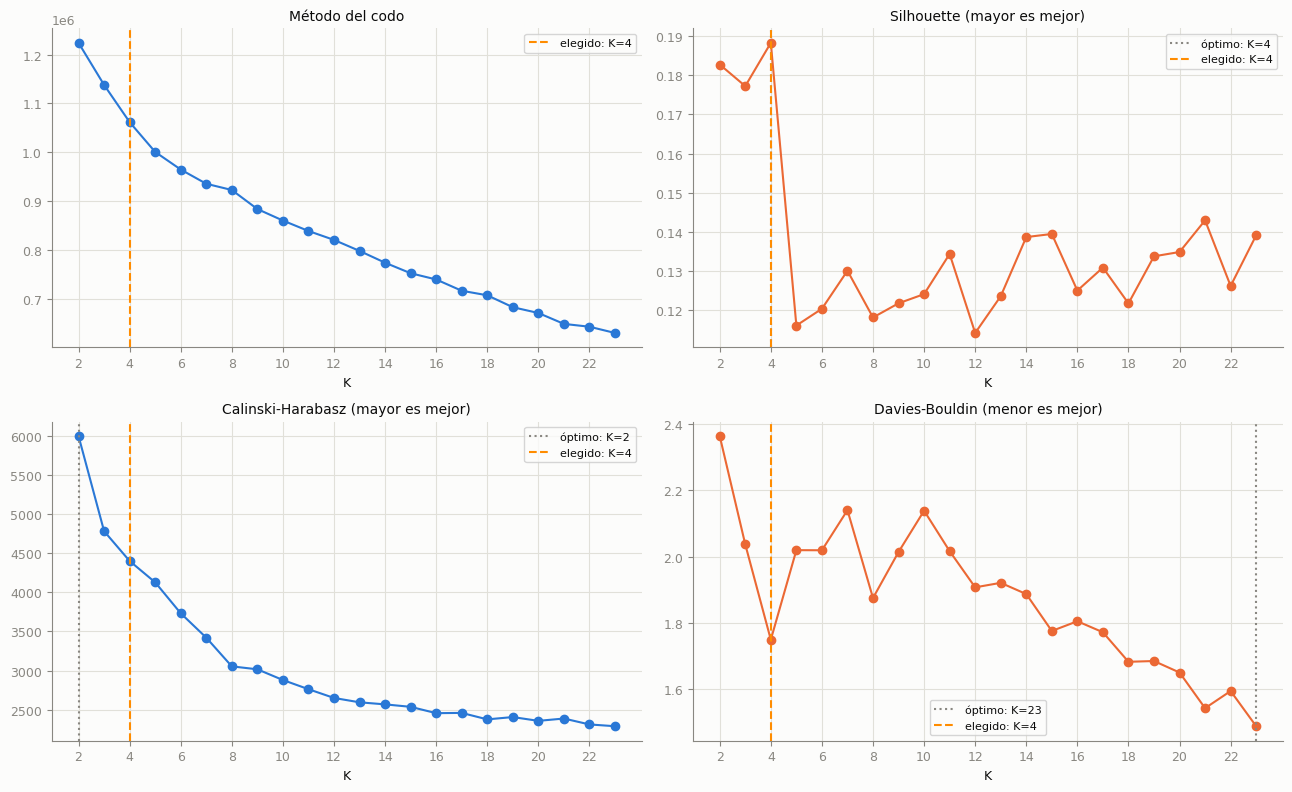

In [206]:
inercia_total = KMeans(n_clusters=1, random_state=42, n_init=10).fit(df_modelo).inertia_
print("Inercia total (K=1):", round(inercia_total, 2))

rango_k = range(2, 24)
diagnostico_k = []

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(df_modelo)
    diagnostico_k.append({
        "K": k,
        "Inercia (WCSS)": modelo.inertia_,
        "Inercia explicada (%)": 100 * (1 - modelo.inertia_ / inercia_total),
        "Silhouette": silhouette_score(df_modelo, etiquetas),
        "Calinski-Harabasz": calinski_harabasz_score(df_modelo, etiquetas),
        "Davies-Bouldin": davies_bouldin_score(df_modelo, etiquetas),
    })

diagnostico_k = pd.DataFrame(diagnostico_k)
diagnostico_k["Reducción vs K anterior (%)"] = (
    -diagnostico_k["Inercia (WCSS)"].pct_change() * 100
)
display(diagnostico_k.round(3))

k_elegido = 4   # <-- fijar después de leer la tabla y los cuatro paneles

paneles = [
    ("Inercia (WCSS)", "Método del codo", COLOR_PRIN, None),
    ("Silhouette", "Silhouette (mayor es mejor)", COLOR_SEC, "max"),
    ("Calinski-Harabasz", "Calinski-Harabasz (mayor es mejor)", COLOR_PRIN, "max"),
    ("Davies-Bouldin", "Davies-Bouldin (menor es mejor)", COLOR_SEC, "min"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, titulo, color, optimo) in zip(axes.flatten(), paneles):
    ax.plot(diagnostico_k["K"], diagnostico_k[col], marker="o", color=color)
    if optimo == "max":
        k_opt = diagnostico_k.loc[diagnostico_k[col].idxmax(), "K"]
    elif optimo == "min":
        k_opt = diagnostico_k.loc[diagnostico_k[col].idxmin(), "K"]
    else:
        k_opt = None
    if k_opt is not None:
        ax.axvline(k_opt, color=COLOR_AXIS, linestyle=":", label=f"óptimo: K={k_opt}")
    ax.axvline(k_elegido, color="darkorange", linestyle="--",
               label=f"elegido: K={k_elegido}")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("K")
    ax.set_xticks(list(rango_k)[::2])
    ax.legend(fontsize=8)
    clean_ax(ax)

plt.tight_layout()
plt.show()

La escogencia de K no estuvo tan fácil en este caso, dado que no es muy claro un valor de K que sea más óptimo de acuerdo a los criterios, pero escogimos `K = 4` porque el Silhouette Score, que es el criterio principal, indica que el mayor score se obtiene con ese valor de K. Asímismo, con Davies-Bouldin, que la idea es minimizarlo, nos da un score que, aunque no sea el más bajo, es considerablemente más bajo que los demás, además que está como en un pico solo para el 4. Calinski-Harabaz no nos da el score más alto, pero de todas formas es alto a comparación de los demás. Con el método del codo si es muy complicado porque no se alcanza a ver un punto de inflexión notorio, entonces lo ignoramos.

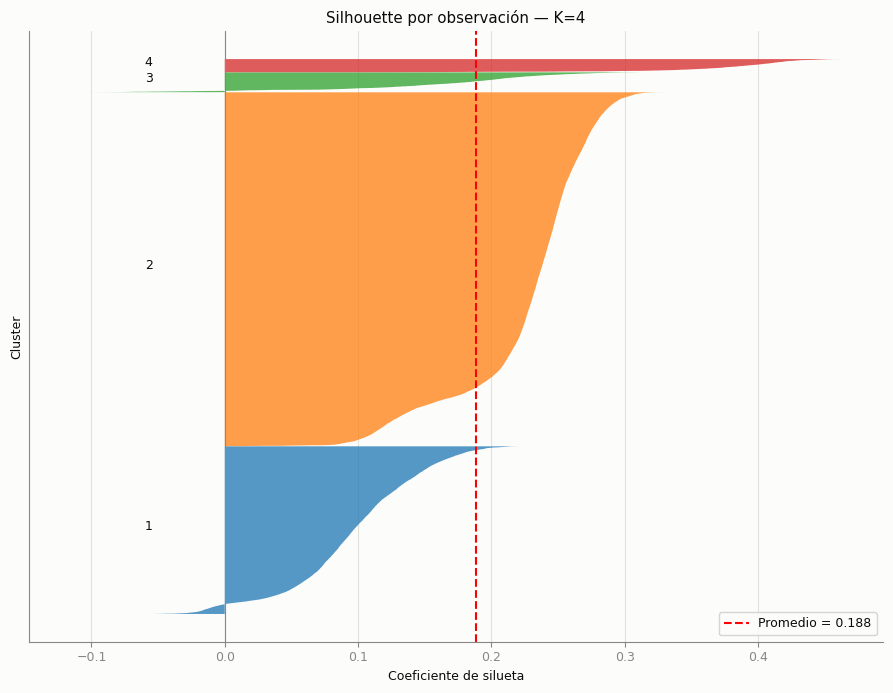

,Silhouette promedio,% con silueta negativa,Observaciones,%
Cluster,,,,
1,0.096,5.845,12455,30.2
2,0.227,0.000,26284,63.8
3,0.161,6.861,1472,3.6
4,0.376,0.000,977,2.4


In [217]:
sil_vals = silhouette_samples(df_modelo, etiquetas)

fig, ax = plt.subplots(figsize=(9, 7))
y_bajo = 10
colores = plt.get_cmap("tab10")
for i in range(k_elegido):
    vals_i = np.sort(sil_vals[etiquetas == i])
    y_alto = y_bajo + len(vals_i)
    ax.fill_betweenx(np.arange(y_bajo, y_alto), 0, vals_i,
                     facecolor=colores(i), alpha=0.75)
    ax.text(-0.06, y_bajo + 0.5 * len(vals_i), str(i + 1), fontsize=9)
    y_bajo = y_alto + 10

ax.axvline(sil_vals.mean(), color="red", linestyle="--",
           label=f"Promedio = {sil_vals.mean():.3f}")
ax.axvline(0, color=COLOR_AXIS, linewidth=0.8)
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.set_title(f"Silhouette por observación — K={k_elegido}")
ax.legend()
clean_ax(ax)
plt.tight_layout()
plt.show()

resumen_sil = pd.DataFrame({
    "Silhouette promedio": pd.Series(sil_vals).groupby(etiquetas + 1).mean(),
    "% con silueta negativa": pd.Series(sil_vals < 0).groupby(etiquetas + 1).mean() * 100,
    "Observaciones": pd.Series(etiquetas + 1).value_counts().sort_index(),
    "%": ((pd.Series(etiquetas + 1).value_counts().sort_index() / len(etiquetas)) * 100).round(1)
}).round(3)
resumen_sil.index.name = "Cluster"
display(resumen_sil)

Acá podemos ver el silhouette score de los 4 clusters que nos quedaron, así como su composición. A primera vista se puede ver que el 1 y el 2 están muy cargados, y la tabla nos ayuda a confirmar eso (más del 90% entre los dos). Vemos que el cluster 2 está muy homogéneo, mientras que el 3 y 4 están bastante heterogéneos, que puede ser causado por su poca cantidad de observaciones. Los scores negativos que se ven son muy bajos, lo cual es muy buena señal porque significa que las observaciones dentro de un cluster se parecen entre sí y no se parecen a las de los otros clusters. Aunque el silhouette promedio no es muy alto, que no haya scores negativos nos dice que la división está bien hecha, simplemente que los supuestos bajo los que trabaja K-Means (clusters esféricos muy delimitados y con tamaño similar, etc.) no se están cumpliendo, pero esto es imposible dentro de un estudio real.

### Punto 4

In [211]:
modelo_kmeans = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
etiquetas = modelo_kmeans.fit_predict(df_modelo)

perfil = df.copy()
perfil["Cluster"] = etiquetas + 1          # 1..K en vez de 0..K-1

tam = perfil["Cluster"].value_counts().sort_index()
display(pd.DataFrame({
    "Observaciones": tam,
    "Porcentaje (%)": (tam / len(perfil) * 100).round(2),
}))

,Observaciones,Porcentaje (%)
Cluster,,
1,12455,30.24
2,26284,63.81
3,1472,3.57
4,977,2.37


Como se dijo antes: los clusters 1 y 2 están muy cargados de observaciones, especialmente el 2. Pero esto nos puede estar diciendo que hay tipos de clientes que son muy comunes y que efectivamente, en la muestra que se tiene, este comportamiento o perfil de cliente es el que más se repite, mientras que los perfiles 3 y 4 son mucho más raros.

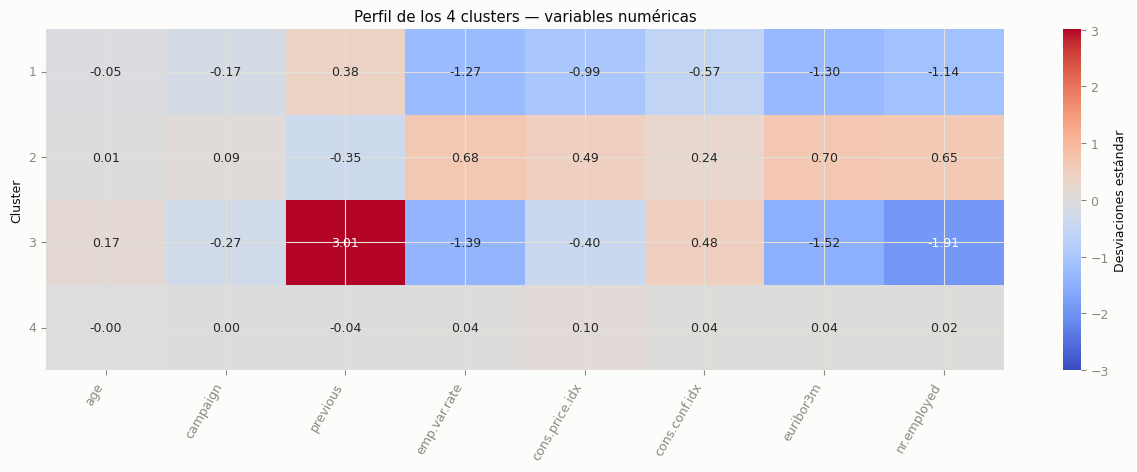

In [212]:
perfil_z = (
    pd.DataFrame(StandardScaler().fit_transform(perfil[num_cols]),
                 columns=num_cols, index=perfil.index)
    .assign(Cluster=perfil["Cluster"])
    .groupby("Cluster").mean()
)

fig, ax = plt.subplots(figsize=(min(14, 1.2 * len(num_cols) + 3), 0.7 * k_elegido + 2))
lim = float(perfil_z.abs().max().max())
sns.heatmap(perfil_z, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-lim, vmax=lim, ax=ax,
            cbar_kws={"label": "Desviaciones estándar"})
ax.set_title(f"Perfil de los {k_elegido} clusters — variables numéricas")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Acá podemos hacer un perfilamiento inicial usando las variables numéricas. Podemos ver que la edad y el número llamadas de esta campaña no ayudan a distinguir entre diferentes clientes: no hay una diferencia significativa entre los que tienen 20 o 50 años, ni a los que no los han llamado por la campaña y los que los han llamado muchas veces. 

El grupo 1 es el de los clientes que más o menos los han llamado para campañas previas y que tienen un índice de confianza un poquito bajo, y que su tasa de variación de empleo, índice de precios al consumidor, tasa euribor y número de empleados es bajo.

El grupo 2 es de los que no los han llamado tanto, pero tienen una tasa de variación de empleo, índice de precios al consumidor tasa euribor y número de empleados más alto que el promedio. Un poco opuesto al grupo 1, pero no se va muy al extremo, y no está tan influenciado por el índice de confianza.

El 3 vemos que son a los que más han llamado en campañas pasadas, aunque para esta campaña los han llamado menos veces que al resto, no tienen muchos empleados (a comparación del promedio), y su tasa euribor y de variación de empleo son bajas. Con un índice de precios a consumidor un poquito bajo, pero un índice de confianza más o menos alto. Están un poco más llevados al extremo en las variables.

Los del grupo 4 vemos que son los que no se diferencian mucho del resto, ya que son muy promedio en todo. Puede que por esto sean el menos común, ya que siempre hay algo que distingue a cada persona del resto.

In [213]:
for col in cat_cols:
    composicion = pd.crosstab(perfil["Cluster"], perfil[col], normalize="index") * 100
    global_pct = perfil[col].value_counts(normalize=True) * 100
    lift = composicion / global_pct

    print(f"\n{'='*70}\n{col}\n{'='*70}")
    print("Composición dentro de cada cluster (%):")
    display(composicion.round(1))
    print("Lift (1.0 = igual que el total; >1.5 = sobrerrepresentado):")
    display(lift.round(2))


job
Composición dentro de cada cluster (%):


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
Cluster,,,,,,,,,,,,
1,26.0,21.7,3.3,1.6,7.1,6.0,3.4,9.6,4.4,13.9,2.5,0.5
2,24.8,23.5,3.8,3.0,7.1,2.9,3.5,9.9,0.7,17.6,2.3,0.9
3,30.4,8.6,1.8,2.7,7.0,11.5,2.2,5.1,9.3,15.7,4.4,1.4
4,22.9,24.6,3.7,3.0,7.3,4.3,4.1,10.3,1.9,14.6,2.8,0.5


Lift (1.0 = igual que el total; >1.5 = sobrerrepresentado):


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
Cluster,,,,,,,,,,,,
1,1.03,0.97,0.93,0.64,1.00,1.43,0.99,1.00,2.05,0.85,1.02,0.63
2,0.98,1.05,1.06,1.16,1.00,0.70,1.02,1.02,0.32,1.08,0.94,1.15
3,1.20,0.38,0.50,1.06,0.99,2.77,0.63,0.53,4.38,0.96,1.79,1.70
4,0.91,1.09,1.04,1.15,1.02,1.03,1.19,1.07,0.92,0.89,1.12,0.64



marital
Composición dentro de cada cluster (%):


...

poutcome,failure,nonexistent,success
Cluster,,,
1,3.13,0.78,0.00
2,0.00,1.16,0.00
3,0.75,0.00,27.68
4,1.10,1.01,0.46



pweeks
Composición dentro de cada cluster (%):


pweeks,una_semana,dos_semanas,tres_semanas,cuatro_semanas,nunca
Cluster,,,,,
1,0.0,0.1,0.1,0.0,99.8
2,0.0,0.0,0.0,0.0,100.0
3,75.3,20.1,4.1,0.3,0.2
4,0.9,1.2,0.0,0.0,97.9


Lift (1.0 = igual que el total; >1.5 = sobrerrepresentado):


pweeks,una_semana,dos_semanas,tres_semanas,cuatro_semanas,nunca
Cluster,,,,,
1,0.00,0.08,0.63,1.24,1.04
2,0.00,0.00,0.00,0.00,1.04
3,27.76,26.21,22.69,17.49,0.00
4,0.34,1.60,0.00,0.00,1.02
